## Compare unsupervised clusters vs supervised mood model

1. **Emotify-trained K-Means on the Kaggle test split** — cluster IDs are arbitrary; report **Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)** against true moods, plus a **Hungarian-aligned** confusion-style heatmap (optimal cluster↔mood permutation).
2. **Supervised model on Emotify** — retrain on the Kaggle training split with the same tuned hyperparameters as in `jaschacomments_5s.ipynb` (update the dict if you re-tune). Compare partitions with **ARI** between K-Means labels and predicted moods.
3. **Disagreement spotlight** — list tracks where the two views diverge most (configurable count), with absolute paths for listening.

In [1]:
import os
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    confusion_matrix,
    normalized_mutual_info_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    from catboost import CatBoostClassifier

    _HAS_CAT = True
except ImportError:
    CatBoostClassifier = None
    _HAS_CAT = False

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path(".").resolve()
ARTIFACTS_DIR = BASE_DIR / "/content/drive/MyDrive/thesis/artifacts"
CLUSTERING_ARTIFACT_PATH = ARTIFACTS_DIR / "emotify_kmeans_tabular.joblib"

# Must match the tabular sample cap in jaschacomments_5s.ipynb (SAMPLES_PER_CLASS) if you want identical splits.
SAMPLES_PER_MOOD_KAGGLE = 5

DATASET_PATH = BASE_DIR / "/content/drive/MyDrive/thesis/dataset"
MOODS = ["aggressive", "dramatic", "happy", "romantic", "sad"]
REF_SEED = 42

# How many high-disagreement Emotify tracks to list at the end.
DISAGREEMENT_SAMPLE_COUNT = 10

# Best XGB (multiclass) params: {'subsample': 0.85, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.85}

# Tuned hyperparameters copied from jaschacomments_5s.ipynb outputs (edit after re-running search).
BEST_XGB_PARAMS = {
    "subsample": 0.85,
    "n_estimators": 500,
    "min_child_weight": 1,
    "max_depth": 9,
    "learning_rate": 0.1,
    "colsample_bytree": 0.85,
}
# Best CatBoost params: {'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 600, 'depth': 10}
BEST_CATBOOST_PARAMS = {
    "learning_rate": 0.03,
    "l2_leaf_reg": 1,
    "iterations": 600,
    "depth": 10,
}

Mounted at /content/drive


In [2]:
def extract_features(file_path):
    """Same definition as clustering / jaschacomments_5s."""
    try:
        y, sr = librosa.load(file_path, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast.T, axis=0)
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        return np.hstack((mfcc_mean, chroma_mean, contrast_mean, zcr_mean))
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


def build_kaggle_tabular(dataset_path: Path, moods, n_per_class: int):
    feats, labels = [], []
    for mood in moods:
        folder = dataset_path / mood
        files = sorted(os.listdir(folder))[:n_per_class]
        for fn in files:
            fp = str((folder / fn).resolve())
            v = extract_features(fp)
            if v is not None:
                feats.append(v)
                labels.append(mood)
    return np.asarray(feats, dtype=np.float32), np.asarray(labels)


def hungarian_cluster_to_class_labels(y_true_class, y_cluster, n_clusters: int, n_classes: int):
    """Return relabeled clusters 0..K-1 aligned to maximize overlap with y_true (integer class indices)."""
    n_lab = max(n_clusters, n_classes)
    ct = confusion_matrix(y_cluster, y_true_class, labels=list(range(n_lab)))
    # rows = cluster, cols = true mood
    r, c = linear_sum_assignment(-ct)
    remap = {int(ri): int(ci) for ri, ci in zip(r, c)}
    y_mapped = np.array([remap.get(int(k), -1) for k in y_cluster], dtype=int)
    return y_mapped, ct, r, c


def plot_contingency(ct, row_names, col_names, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(ct, aspect="auto", cmap="Blues")
    ax.set_xticks(np.arange(len(col_names)))
    ax.set_yticks(np.arange(len(row_names)))
    ax.set_xticklabels(col_names, rotation=45, ha="right")
    ax.set_yticklabels(row_names)
    ax.set_title(title)
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            ax.text(j, i, int(ct[i, j]), ha="center", va="center", color="black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

In [3]:
bundle = joblib.load(CLUSTERING_ARTIFACT_PATH)
kmeans = bundle["kmeans"]
scaler = bundle["scaler"]
X_emotify = bundle["X_emotify"]
emotify_paths = bundle["paths"]
emotify_genres = bundle["genre_labels"]
emotify_clusters = bundle["cluster_labels"]
print("Loaded clustering artifact:", CLUSTERING_ARTIFACT_PATH)
print("Emotify matrix:", X_emotify.shape)

Loaded clustering artifact: /content/drive/MyDrive/thesis/artifacts/emotify_kmeans_tabular.joblib
Emotify matrix: (400, 33)


### Emotify K-Means applied to the Kaggle tabular test split

The scaler and centroids were fit on Emotify only; this answers: *if we assign each Kaggle test file to the nearest Emotify-defined cluster, do those groups line up with the true mood labels?*

--- K-Means (Emotify-trained) vs Kaggle test moods ---
Adjusted Rand index: 0.0000
NMI:               0.9057
(1.0 ARI = identical partitions up to label permutation; ~0 = chance.)
Accuracy after Hungarian cluster→mood alignment: 0.8000


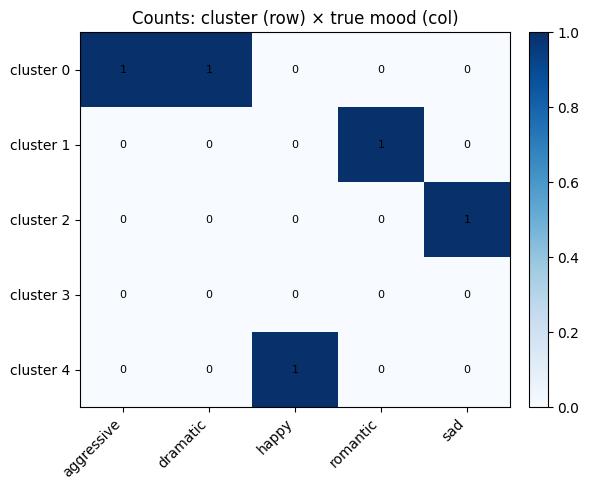

In [4]:
X_kag, y_kag_str = build_kaggle_tabular(DATASET_PATH, MOODS, SAMPLES_PER_MOOD_KAGGLE)
le = LabelEncoder()
y_kag = le.fit_transform(y_kag_str)
class_names = le.classes_
n_classes = len(class_names)

X_ref_tr, X_ref_te, y_ref_tr, y_ref_te = train_test_split(
    X_kag,
    y_kag,
    test_size=0.2,
    stratify=y_kag,
    random_state=REF_SEED,
)

X_te_scaled = scaler.transform(X_ref_te)
clusters_on_test = kmeans.predict(X_te_scaled)

ari_test = adjusted_rand_score(y_ref_te, clusters_on_test)
nmi_test = normalized_mutual_info_score(y_ref_te, clusters_on_test)
print("--- K-Means (Emotify-trained) vs Kaggle test moods ---")
print(f"Adjusted Rand index: {ari_test:.4f}")
print(f"NMI:               {nmi_test:.4f}")
print("(1.0 ARI = identical partitions up to label permutation; ~0 = chance.)")

y_test_mapped, ct_test, row_ind, col_ind = hungarian_cluster_to_class_labels(
    y_ref_te, clusters_on_test, n_clusters=kmeans.n_clusters, n_classes=n_classes
)
valid = y_test_mapped >= 0
acc_aligned = accuracy_score(y_ref_te[valid], y_test_mapped[valid])
print(f"Accuracy after Hungarian cluster→mood alignment: {acc_aligned:.4f}")

row_names = [f"cluster {i}" for i in range(ct_test.shape[0])]
plot_contingency(ct_test, row_names, list(class_names), "Counts: cluster (row) × true mood (col)")

**How to read A:** If ARI/NMI are well above chance, acoustic structure in Emotify’s five clusters partially matches the mood taxonomy on the Kaggle set. Low scores are expected when the two corpora differ (genre MP3s vs curated mood WAVs) or when five clusters are not mood-shaped.

### Supervised mood model on Emotify features

Train on the **same** Kaggle train split (`REF_SEED`), then predict moods for Emotify tracks and compare to Emotify K-Means labels via ARI and a contingency plot.

Supervised model: XGBoost (CatBoost not installed)
--- Supervised predictions vs Emotify K-Means ---
Adjusted Rand index: 0.1380
NMI:               0.2114


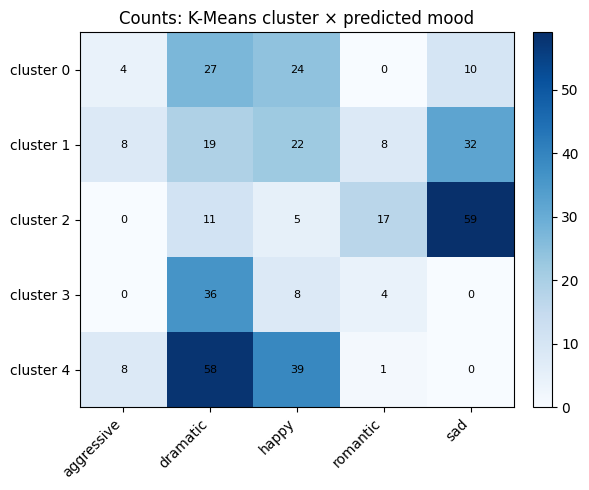

In [5]:
USE_CATBOOST = _HAS_CAT

if USE_CATBOOST:
    sup = CatBoostClassifier(
        **BEST_CATBOOST_PARAMS,
        loss_function="MultiClass",
        random_seed=REF_SEED,
        verbose=False,
    )
    sup.fit(X_ref_tr, y_ref_tr)
    model_name = "CatBoost (tuned params from jaschacomments_5s)"
else:
    sup = XGBClassifier(
        **BEST_XGB_PARAMS,
        random_state=REF_SEED,
        objective="multi:softprob",
        tree_method="hist",
    )
    sup.fit(X_ref_tr, y_ref_tr)
    model_name = "XGBoost (CatBoost not installed)"

print("Supervised model:", model_name)

pred_emotify = np.ravel(sup.predict(X_emotify))  # CatBoost can return (n, 1) instead of (n,)
P = sup.predict_proba(X_emotify)

ari_em = adjusted_rand_score(emotify_clusters, pred_emotify)
nmi_em = normalized_mutual_info_score(emotify_clusters, pred_emotify)
print("--- Supervised predictions vs Emotify K-Means ---")
print(f"Adjusted Rand index: {ari_em:.4f}")
print(f"NMI:               {nmi_em:.4f}")

ct_em = confusion_matrix(emotify_clusters, pred_emotify, labels=list(range(n_classes)))
row_names_c = [f"cluster {i}" for i in range(ct_em.shape[0])]
plot_contingency(ct_em, row_names_c, list(class_names), "Counts: K-Means cluster × predicted mood")

**How to read B:** High ARI means the tree model’s mood assignments carve Emotify into almost the same groups as K-Means (up to permutation). Low ARI means moods from the Kaggle-trained classifier do not coincide with unsupervised geometry on Emotify.

### Tracks where the two methods disagree most

We Hungarian-align **clusters → moods** using the co-occurrence of (cluster, supervised prediction), then flag samples whose predicted mood differs from the mood assigned to their cluster. **Disagreement strength** = \(1 - p(\text{cluster-mood})\) from the classifier probabilities after mapping cluster id to its aligned mood index (higher = classifier is more confident in a different mood than the cluster’s global partner).

In [6]:
y_row, pred_col = emotify_clusters, pred_emotify
ct_align = confusion_matrix(y_row, pred_col, labels=list(range(n_classes)))
r_ind, c_ind = linear_sum_assignment(-ct_align)
cluster_to_mood = {int(r): int(c) for r, c in zip(r_ind, c_ind)}
cluster_mood_for_sample = np.array([cluster_to_mood[int(c)] for c in emotify_clusters])

disagree_mask = pred_emotify != cluster_mood_for_sample
# strength: classifier probability mass *not* on the Hungarian partner mood
p_partner = P[np.arange(len(pred_emotify)), cluster_mood_for_sample]
strength = 1.0 - p_partner

idx = np.where(disagree_mask)[0]
if len(idx) == 0:
    print("No disagreements under Hungarian cluster→mood alignment.")
    disagree_df = pd.DataFrame()
else:
    order = idx[np.argsort(-strength[idx])][:DISAGREEMENT_SAMPLE_COUNT]
    rows = []
    for i in order:
        rows.append(
            {
                "path": emotify_paths[i],
                "genre_folder": emotify_genres[i],
                "kmeans_cluster": int(emotify_clusters[i]),
                "hungarian_mood_for_cluster": class_names[cluster_mood_for_sample[i]],
                "supervised_pred_mood": class_names[pred_emotify[i]],
                "disagreement_strength_1_minus_p_partner": float(strength[i]),
            }
        )
    disagree_df = pd.DataFrame(rows)
    display(disagree_df)

# Plain list for quick copy/paste into a player or terminal
if len(disagree_df):
    print("\nAbsolute paths (listen in order of disagreement strength):")
    for p in disagree_df["path"]:
        print(p)

,path,genre_folder,kmeans_cluster,hungarian_mood_for_cluster,supervised_pred_mood,disagreement_strength_1_minus_p_partner
0,/content/drive/MyDrive/thesis/emotifymusic/ele...,electronic,1,aggressive,sad,0.980750
1,/content/drive/MyDrive/thesis/emotifymusic/ele...,electronic,2,sad,romantic,0.979061
2,/content/drive/MyDrive/thesis/emotifymusic/roc...,rock,1,aggressive,romantic,0.979054
3,/content/drive/MyDrive/thesis/emotifymusic/cla...,classical,2,sad,romantic,0.979038
4,/content/drive/MyDrive/thesis/emotifymusic/pop...,pop,3,romantic,happy,0.978758
5,/content/drive/MyDrive/thesis/emotifymusic/ele...,electronic,1,aggressive,sad,0.978383
6,/content/drive/MyDrive/thesis/emotifymusic/cla...,classical,2,sad,romantic,0.977621
7,/content/drive/MyDrive/thesis/emotifymusic/roc...,rock,1,aggressive,sad,0.977362
8,/content/drive/MyDrive/thesis/emotifymusic/roc...,rock,3,romantic,dramatic,0.976602
9,/content/drive/MyDrive/thesis/emotifymusic/ele...,electronic,1,aggressive,sad,0.976471



Absolute paths (listen in order of disagreement strength):
/content/drive/MyDrive/thesis/emotifymusic/electronic/79.mp3
/content/drive/MyDrive/thesis/emotifymusic/electronic/97.mp3
/content/drive/MyDrive/thesis/emotifymusic/rock/93.mp3
/content/drive/MyDrive/thesis/emotifymusic/classical/67.mp3
/content/drive/MyDrive/thesis/emotifymusic/pop/42.mp3
/content/drive/MyDrive/thesis/emotifymusic/electronic/62.mp3
/content/drive/MyDrive/thesis/emotifymusic/classical/39.mp3
/content/drive/MyDrive/thesis/emotifymusic/rock/50.mp3
/content/drive/MyDrive/thesis/emotifymusic/rock/29.mp3
/content/drive/MyDrive/thesis/emotifymusic/electronic/1.mp3
